In [1]:
import kagglehub
path = kagglehub.dataset_download("rakannimer/air-passengers")

Using Colab cache for faster access to the 'air-passengers' dataset.


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [3]:
files = os.listdir(path)
csv_file = os.path.join(path, 'AirPassengers.csv')

df = pd.read_csv(csv_file)
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [5]:
df.isna().sum()

,0
Month,0
#Passengers,0


## Data Preprocessing

In [6]:
# Convert to float and reshape to 2D
data = df['#Passengers'].values.astype(float).reshape(-1, 1)

In [7]:
# For Feature Scaling aka Normalization, we use MinMaxScaler because LSTM uses Tanh and Sigmoid which are sensitive between -1 and 1
# => use MMScaler to cluster the value to be around 0 and 1

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [8]:
# train-test split
train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [9]:
"""
Sequence helps the model to not forget about the previous data:
The Input (X): The number of passengers from January to December.
The Output (y): The predicted number of passengers for the next January.

Think of it like teaching a human to recognize a song.
If you play just one note, they can't guess the song.
If you play a sequence of 5 notes, they have a chance.
"""

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window]) # The sequence
        y.append(data[i + window])     # The next value
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, window=12)
X_test, y_test = create_sequences(test_data, window=12)

print(X_train)

[[[0.01544402]
  [0.02702703]
  [0.05405405]
  ...
  [0.02895753]
  [0.        ]
  [0.02702703]]

 [[0.02702703]
  [0.05405405]
  [0.04826255]
  ...
  [0.        ]
  [0.02702703]
  [0.02123552]]

 [[0.05405405]
  [0.04826255]
  [0.03281853]
  ...
  [0.02702703]
  [0.02123552]
  [0.04247104]]

 ...

 [[0.48455598]
  [0.61389961]
  [0.6969112 ]
  ...
  [0.41312741]
  [0.4980695 ]
  [0.47104247]]

 [[0.61389961]
  [0.6969112 ]
  [0.7007722 ]
  ...
  [0.4980695 ]
  [0.47104247]
  [0.5       ]]

 [[0.6969112 ]
  [0.7007722 ]
  [0.57915058]
  ...
  [0.47104247]
  [0.5       ]
  [0.63899614]]]


In [10]:
# Convert to tensor
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

## LSTM

In [11]:
class LSTMModel(nn.Module):
    """
      args explain:
      input_dim: number of input features
      hidden_dim: number of neurons in LSTM
      layer_dim: number of LSTM layers being stacked
      output_dim: number of output features
    """

    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None, c0=None):
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(
                0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(
                0), self.hidden_dim).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # Take only the final model "thought"
        return out, hn, cn

In [12]:
model = LSTMModel(input_dim=1, hidden_dim=64, layer_dim=1, output_dim=1)
"""
input_dim: #pass in a timestamp => 1
hidden_dim: small datasets => 64
layer_dim: number of lstm layer stacked => small so 1
output_dim: #pass next month => 1
"""
criterion = nn.MSELoss()  # Mean Squared Error for Regression (this depends on my task, if classi => use CrossEntropyLoss)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [13]:
num_epochs = 100
# Here we dont want to Statefully Train because its not a loop
# for the sine wave, the pattern repeat while if we keeping this then the model might understand that 1960 is the previous step of 1949
# since the data state isn't be wiped off before starting a new epoch

for epoch in range(num_epochs):
    model.train()

    # 1. Clear gradients from the previous lap
    optimizer.zero_grad()

    # 2. Forward pass
    # Passing None for states tells your model to start with a blank memory (zeros)
    # We use _ for the states because we don't need to save them for the next epoch
    outputs, _, _ = model(X_train_tensor, h0=None, c0=None)

    # 3. Calculate Loss
    loss = criterion(outputs, y_train_tensor)

    # 4. Backpropagation (Calculate gradients)
    loss.backward()

    # 5. Update Weights
    optimizer.step()

    # Logging every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.0459
Epoch [20/100], Loss: 0.0271
Epoch [30/100], Loss: 0.0198
Epoch [40/100], Loss: 0.0140
Epoch [50/100], Loss: 0.0057
Epoch [60/100], Loss: 0.0053
Epoch [70/100], Loss: 0.0048
Epoch [80/100], Loss: 0.0047
Epoch [90/100], Loss: 0.0046
Epoch [100/100], Loss: 0.0045


## Model Evaluation

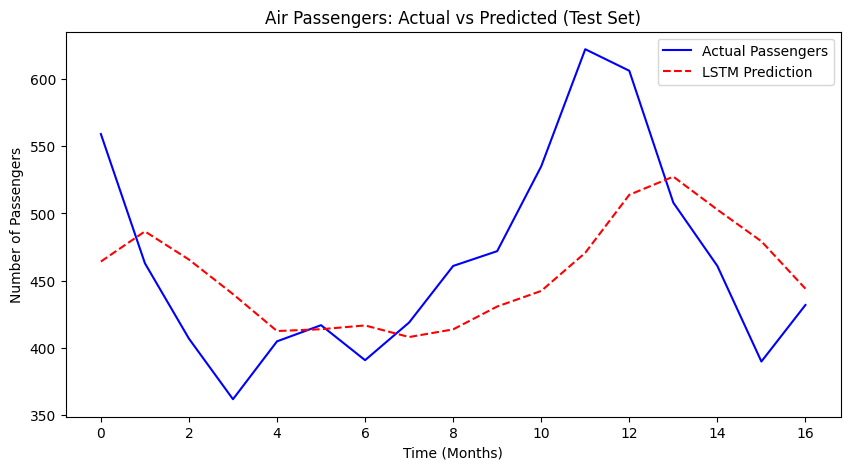

In [14]:
# 1. Set model to evaluation mode
model.eval()

# 2. Turn off gradient calculation (saves memory/time)
with torch.no_grad():
    # We only need the first output (predictions)
    test_predict, _, _ = model(X_test_tensor)

# 3. Convert tensors back to NumPy arrays
test_predict = test_predict.numpy()
y_test_actual = y_test_tensor.numpy()

# 4. Invert the scaling
test_predict_orig = scaler.inverse_transform(test_predict)
y_test_actual_orig = scaler.inverse_transform(y_test_actual)

# 5. Create the plot
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual_orig, label='Actual Passengers', color='blue')
plt.plot(test_predict_orig, label='LSTM Prediction', color='red', linestyle='--')

plt.title('Air Passengers: Actual vs Predicted (Test Set)')
plt.xlabel('Time (Months)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

=> Might need to increase epoch, hidden_dim num or increase the dataset itself

In [16]:
# 1. Pick the last 12 months from your data using the name from your notebook
last_window = data_scaled[-12:]

# 2. Reshape and convert to a PyTorch tensor
# Shape: (1, 12, 1) -> (batch of 1, sequence of 12, 1 feature)
input_tensor = torch.from_numpy(last_window).float().view(1, 12, 1)

# 3. Put the model in evaluation mode and predict
model.eval()
with torch.no_grad():
    prediction_scaled, _, _ = model(input_tensor)

# 4. Convert the scaled result back to a real passenger number
# We use the 'scaler' you defined in cell 13
prediction_actual = scaler.inverse_transform(prediction_scaled.numpy())

print(f"The predicted number of passengers for the next month is: {prediction_actual[0][0]:.2f}")

The predicted number of passengers for the next month is: 442.04
